In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('zuu crew scores.csv')
df.head(5)

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
3,Nisal Gamage,1,74.5,63.9,7,0,76.8,1.7,Production-Ready ML Systems,100.0
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1


In [6]:
df = df[df['CourseName'] == 'Foundations of ML']
df.head()

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1
7,Chamath Perera,3,86.5,88.0,5,0,23.9,1.3,Foundations of ML,68.2


In [7]:
X = df[ 'TotalHours' ].values.reshape(-1, 1)
Y = df[ 'CapstoneScore' ].values

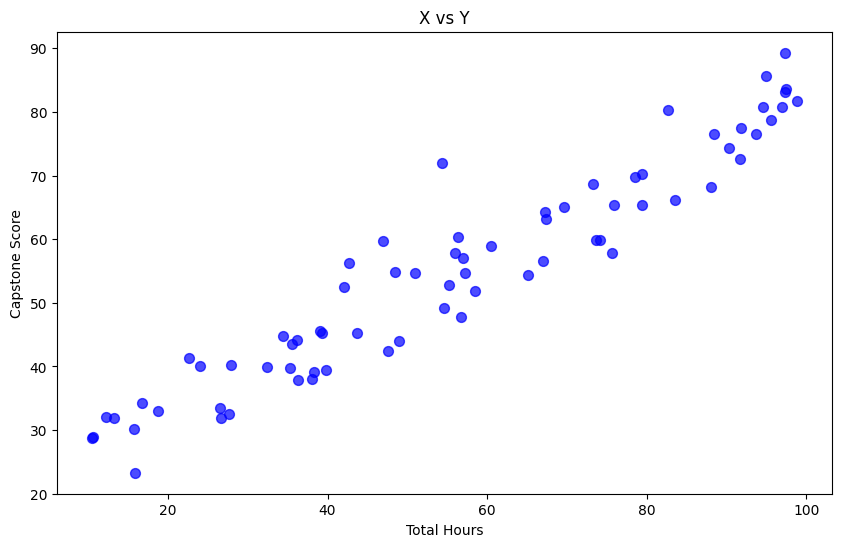

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.7, color='blue', s=50)
plt.xlabel('Total Hours')
plt.ylabel('Capstone Score')
plt.title('X vs Y')
plt.show()

In [9]:
def compute_cost(X, Y, beta):
    """ 
        X : (m, n)
        Y : (m, )
        beta : (beta0, beta1)

        MSE = >  sum(( y_hat - y ) ** 2)
        X.dot(beta) => beta0 + beta1.x1 + ...... + betaj.xj + ...... + betan.xn   
    """

    m= len(Y)
    y_hat = X.dot(beta)
    cost = ( 1 / (2 * m) ) * np.sum((y_hat - Y) ** 2)
    return cost

def gradient_descent(X, Y, beta, lr, n_iter):
    """ 
    X : (m, n) -> after adding bias : (m, n+1) -> (72, 2) | If I take transpose -> (2, 72)

    dj/dbetaj = (1 / m) * X.T * (y_hat - y)
    """

    m = len(Y)
    cost_history = []

    for i in range(n_iter):

        y_hat = X.dot(beta)
        gradients = (1 / m) * X.T.dot(y_hat - Y)

        beta = beta - lr * gradients
        cost = compute_cost(X, Y, beta)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration: {i}: cost: {cost:.4f} ")

    return cost_history,beta     

In [10]:
""" 
    y_hat = beta0.x0 + beta1.x1; xo = 1
    X = [1, x1]

"""


X_with_bias = np.column_stack([np.ones((len(X))), X])
X_with_bias

array([[ 1. , 43.7],
       [ 1. , 95.6],
       [ 1. , 75.9],
       [ 1. , 24. ],
       [ 1. , 88. ],
       [ 1. , 97.3],
       [ 1. , 26.5],
       [ 1. , 57.2],
       [ 1. , 48.9],
       [ 1. , 36.2],
       [ 1. , 65.1],
       [ 1. , 22.6],
       [ 1. , 36.3],
       [ 1. , 51. ],
       [ 1. , 56.3],
       [ 1. , 15.9],
       [ 1. , 96.9],
       [ 1. , 18.8],
       [ 1. , 54.6],
       [ 1. , 91.8],
       [ 1. , 69.6],
       [ 1. , 38.1],
       [ 1. , 26.6],
       [ 1. , 97.3],
       [ 1. , 94.6],
       [ 1. , 27.6],
       [ 1. , 39.3],
       [ 1. , 34.4],
       [ 1. , 42.1],
       [ 1. , 35.3],
       [ 1. , 98.8],
       [ 1. , 27.9],
       [ 1. , 10.5],
       [ 1. , 73.6],
       [ 1. , 75.6],
       [ 1. , 79.4],
       [ 1. , 16.7],
       [ 1. , 39.8],
       [ 1. , 15.7],
       [ 1. , 67.4],
       [ 1. , 74.2],
       [ 1. , 78.5],
       [ 1. , 60.5],
       [ 1. , 79.4],
       [ 1. , 54.4],
       [ 1. , 57. ],
       [ 1. , 48.5],
       [ 1. ,

In [11]:
beta = np.random.randn(2)
print(f"beta values : {beta}")

lr = 0.000001
n_iter = 10000

beta values : [ 1.18816761 -0.63736172]


In [12]:
cost_history, beta = gradient_descent(X_with_bias, Y, beta, lr, n_iter)

Iteration: 0: cost: 4544.4800 
Iteration: 100: cost: 2126.5877 
Iteration: 200: cost: 1008.6848 
Iteration: 300: cost: 491.8265 
Iteration: 400: cost: 252.8585 
Iteration: 500: cost: 142.3720 
Iteration: 600: cost: 91.2884 
Iteration: 700: cost: 67.6694 
Iteration: 800: cost: 56.7486 
Iteration: 900: cost: 51.6987 
Iteration: 1000: cost: 49.3633 
Iteration: 1100: cost: 48.2828 
Iteration: 1200: cost: 47.7825 
Iteration: 1300: cost: 47.5506 
Iteration: 1400: cost: 47.4427 
Iteration: 1500: cost: 47.3921 
Iteration: 1600: cost: 47.3680 
Iteration: 1700: cost: 47.3562 
Iteration: 1800: cost: 47.3501 
Iteration: 1900: cost: 47.3465 
Iteration: 2000: cost: 47.3442 
Iteration: 2100: cost: 47.3425 
Iteration: 2200: cost: 47.3410 
Iteration: 2300: cost: 47.3396 
Iteration: 2400: cost: 47.3383 
Iteration: 2500: cost: 47.3370 
Iteration: 2600: cost: 47.3357 
Iteration: 2700: cost: 47.3345 
Iteration: 2800: cost: 47.3332 
Iteration: 2900: cost: 47.3319 
Iteration: 3000: cost: 47.3307 
Iteration: 

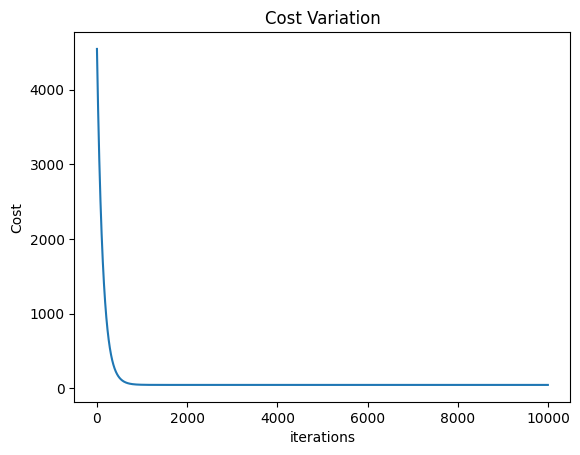

In [13]:
plt.plot(cost_history)
plt.title("Cost Variation")
plt.xlabel("iterations")
plt.ylabel("Cost")
plt.show()

In [14]:
print(f"beat beta : {beta}")

beat beta : [1.2461145  0.89635754]


In [15]:
x_min, x_max = float(np.min(X)), float(np.max(X))
x_interval = np.linspace(x_min, x_max, 100)
x_interval_with_bias = np.column_stack([np.ones((len(x_interval))), x_interval])
y_hat_interval = x_interval_with_bias.dot(beta)
y_hat_interval

array([10.65786863, 11.45734712, 12.25682561, 13.0563041 , 13.85578259,
       14.65526108, 15.45473957, 16.25421806, 17.05369655, 17.85317504,
       18.65265353, 19.45213202, 20.25161051, 21.051089  , 21.85056749,
       22.65004598, 23.44952447, 24.24900296, 25.04848145, 25.84795994,
       26.64743843, 27.44691692, 28.24639541, 29.0458739 , 29.84535239,
       30.64483088, 31.44430937, 32.24378786, 33.04326635, 33.84274484,
       34.64222333, 35.44170182, 36.24118031, 37.0406588 , 37.84013729,
       38.63961578, 39.43909427, 40.23857276, 41.03805125, 41.83752974,
       42.63700823, 43.43648672, 44.2359652 , 45.03544369, 45.83492218,
       46.63440067, 47.43387916, 48.23335765, 49.03283614, 49.83231463,
       50.63179312, 51.43127161, 52.2307501 , 53.03022859, 53.82970708,
       54.62918557, 55.42866406, 56.22814255, 57.02762104, 57.82709953,
       58.62657802, 59.42605651, 60.225535  , 61.02501349, 61.82449198,
       62.62397047, 63.42344896, 64.22292745, 65.02240594, 65.82

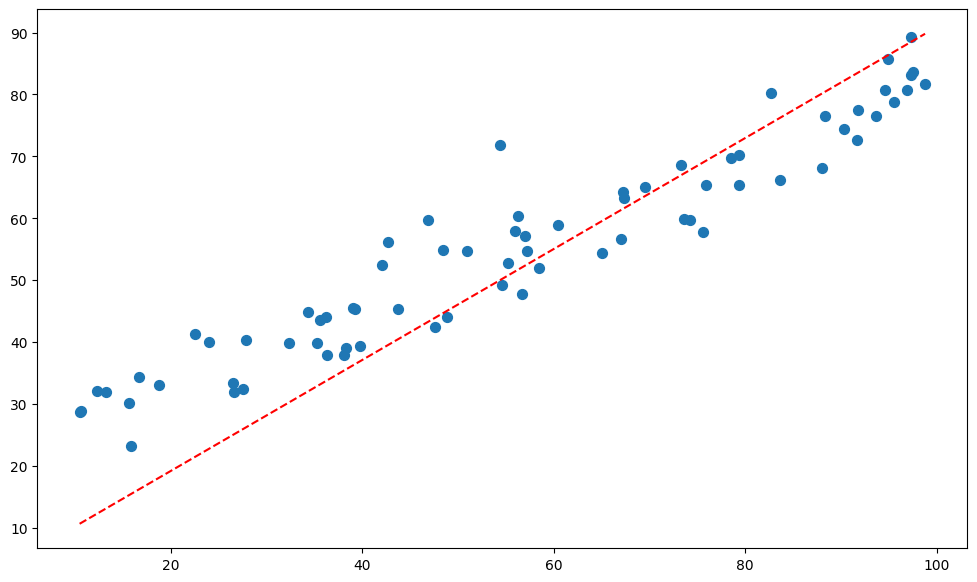

In [16]:
plt.figure(figsize=(12, 7))

plt.scatter(X, Y, s=50, label="actual data")

plt.plot(x_interval, y_hat_interval, 'r--', label="fitted line")

plt.show()

##### how to evaluate ?

    - MSE : Mean squared error
    - RMSE : Root mean squared error
    - MAE : Mean absolute error
    - R^2 : R-squared

In [18]:
Y_hat = X_with_bias.dot(beta)
Y_hat

array([40.41693885, 86.937895  , 69.27965153, 22.75869538, 80.12557773,
       88.46170282, 24.99958922, 52.5177656 , 45.07799804, 33.69425733,
       59.59899014, 21.50379483, 33.78389308, 46.96034887, 51.71104381,
       15.49819933, 88.1031598 , 18.09763619, 50.187236  , 83.53173636,
       63.63259905, 35.39733665, 25.08922498, 88.46170282, 86.04153747,
       25.98558251, 36.47296569, 32.08081376, 38.98276679, 32.88753554,
       89.80623912, 26.25448977, 10.65786863, 67.2180292 , 69.01074427,
       72.41690291, 16.21528536, 36.92114446, 15.31892783, 61.66061247,
       67.75584372, 71.61018113, 55.47574547, 72.41690291, 50.00796449,
       52.33849409, 44.71945503, 12.2713122 , 61.57097672, 35.57660815,
       83.44210061, 30.28809869, 43.28528297, 85.23481568, 61.30206946,
       80.48412074, 82.18720006, 53.68303039, 75.37488278, 76.18160456,
       10.74750439, 51.44213655, 43.91273324, 86.31044473, 36.29369418,
       52.06958683, 66.94912194, 39.52058132, 88.64097432, 33.15

In [19]:
def MSE(Y,Y_hat):
    e_i = Y - Y_hat
    return np.mean(e_i**2)

def MAE(Y,Y_hat):
    e_i = Y - Y_hat
    return np.mean(np.abs(e_i))

def R2_Score(Y,Y_hat):
    y_mean = np.mean(Y)
    e_i = Y - Y_hat
    std_i = Y - y_mean

    E = np.sum(e_i**2) / np.sum(std_i ** 2)
    return 1 - E

def RMSE(Y,Y_hat):
    e_i = Y - Y_hat
    return np.sqrt(np.mean((Y - Y_hat) ** 2))           

In [20]:
mse = MSE(Y, Y_hat)
mae = MAE(Y, Y_hat)
r2 = R2_Score(Y, Y_hat)
rmse = RMSE(Y,Y_hat)

print(f"MSE : {mse}")
print(f"MAE : {mae}")
print(f"R2 Score : {r2}")
print(f"RMSE : {rmse}")

MSE : 94.48423561289286
MAE : 7.999402332614939
R2 Score : 0.6693219963019381
RMSE : 9.720300181213174
